<a href="https://colab.research.google.com/github/gyxcit/hyperclap/blob/main/hyperclap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. installation

In [1]:
!pip install -q datasets soundfile librosa torchaudio

#1. import

In [39]:
from datasets import load_dataset
from IPython.display import Audio, display
from sklearn.decomposition import PCA
from numpy.linalg import norm

import numpy as np
import librosa
import random
import pandas as pd


#2. load data

In [3]:

# Charge le dataset audio ESC-50 : train split first
esc50 = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
sample = esc50_train[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 2.1 data info

### 2.1.1. data structure

#### ESC-50 Dataset Structure

| Field        | Type               | Description                                                                                     |
|--------------|--------------------|-------------------------------------------------------------------------------------------------|
| `filename`   | `str`              | Name of the audio file (e.g., `1-100032-A-0.wav`).                                             |
| `fold`       | `int` (1 to 5)     | Cross-validation fold number (4 training folds, 1 testing fold).                                |
| `target`     | `int` (0–49)       | Numeric label corresponding to one of the 50 sound classes.                                    |
| `category`   | `str`              | Text name of the class (e.g., `dog`, `rain`, `siren`).                                          |
| `esc10`      | `bool`             | Boolean: `True` if the clip is part of the ESC-10 subset (10 classes with CC BY license).         |
| `src_file`   | `int`              | Original sound ID from Freesound.org.                                                            |
| `take`       | `str`              | Letter indicating a variant of the source recording (e.g., `A`, `B`).                         |
| `audio`      | `AudioDecoder`     | Hugging Face audio object containing the waveform and sampling rate.                            |

---

### List of 50 Sound Classes (ESC-50)

| ID  | Class                  |
|-----|------------------------|
| 00  | airplane               |
| 01  | breathing               |
| 02  | brushing_teeth          |
| 03  | can_opening             |
| 04  | car_horn                |
| 05  | cat                     |
| 06  | chainsaw                |
| 07  | chirping_birds          |
| 08  | church_bells            |
| 09  | clapping                |
| 10  | clock_alarm             |
| 11  | clock_tick              |
| 12  | coughing                |
| 13  | cow                     |
| 14  | crackling_fire          |
| 15  | crickets                |
| 16  | crow                    |
| 17  | crying_baby             |
| 18  | dog                     |
| 19  | door_wood_creaks        |
| 20  | door_wood_knock         |
| 21  | drinking_sipping        |
| 22  | engine                  |
| 23  | fireworks               |
| 24  | footsteps               |
| 25  | frog                    |
| 26  | glass_breaking          |
| 27  | hand_saw                |
| 28  | helicopter              |
| 29  | hen                     |
| 30  | insects                 |
| 31  | keyboard_typing         |
| 32  | laughing                |
| 33  | mouse_click             |
| 34  | pig                     |
| 35  | pouring_water           |
| 36  | rain                    |
| 37  | rooster                 |
| 38  | sea_waves               |
| 39  | sheep                   |
| 40  | siren                   |
| 41  | sneezing                |
| 42  | snoring                 |
| 43  | thunderstorm            |
| 44  | toilet_flush            |
| 45  | train                   |
| 46  | vacuum_cleaner          |
| 47  | washing_machine         |
| 48  | water_drops             |
| 49  | wind                    |

---
**Total number of classes:** 50
**Number of examples per class:** 40


### 2.1.2. general info

#### 2.1.1.0 obvious info

In [4]:
print(esc50_train)

Dataset({
    features: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'audio'],
    num_rows: 2000
})


In [5]:
esc50_train.info

DatasetInfo(description='', citation='', homepage='', license='', features={'filename': Value('string'), 'fold': Value('int64'), 'target': Value('int64'), 'category': Value('string'), 'esc10': Value('bool'), 'src_file': Value('int64'), 'take': Value('string'), 'audio': Audio(sampling_rate=None, decode=True, stream_index=None)}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='esc50', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=882230336, num_examples=2000, shard_lengths=None, dataset_name='esc50')}, download_checksums={'hf://datasets/ashraq/esc50@e3e2a63ffff66b9a9735524551e3818e96af03ee/data/train-00000-of-00002-2f1ab7b824ec751f.parquet': {'num_bytes': 386533721, 'checksum': None}, 'hf://datasets/ashraq/esc50@e3e2a63ffff66b9a9735524551e3818e96af03ee/data/train-00001-of-00002-27425e5c1846b494.parquet': {'num_bytes': 386787270, 'checksum': None}}, download_size=773320991, post_processing_size=None, dataset_size=

#### 2.1.1.1. categoies

In [6]:
categories = esc50_train.unique("category")

In [7]:
categories_sorted = sorted(categories)

# Affiche
print(f"Nombre de classes: {len(categories_sorted)}")
for idx, cat in enumerate(categories_sorted):
    print(f"{idx:02d}: {cat}")

Nombre de classes: 50
00: airplane
01: breathing
02: brushing_teeth
03: can_opening
04: car_horn
05: cat
06: chainsaw
07: chirping_birds
08: church_bells
09: clapping
10: clock_alarm
11: clock_tick
12: coughing
13: cow
14: crackling_fire
15: crickets
16: crow
17: crying_baby
18: dog
19: door_wood_creaks
20: door_wood_knock
21: drinking_sipping
22: engine
23: fireworks
24: footsteps
25: frog
26: glass_breaking
27: hand_saw
28: helicopter
29: hen
30: insects
31: keyboard_typing
32: laughing
33: mouse_click
34: pig
35: pouring_water
36: rain
37: rooster
38: sea_waves
39: sheep
40: siren
41: sneezing
42: snoring
43: thunderstorm
44: toilet_flush
45: train
46: vacuum_cleaner
47: washing_machine
48: water_drops
49: wind


#### 2.1.1.2. counts per label

In [8]:
from collections import Counter

cat_counts = Counter(esc50_train["category"])

for cat, count in cat_counts.items():
    print(f"{cat}: {count}")

dog: 40
chirping_birds: 40
vacuum_cleaner: 40
thunderstorm: 40
door_wood_knock: 40
can_opening: 40
crow: 40
clapping: 40
fireworks: 40
chainsaw: 40
airplane: 40
mouse_click: 40
pouring_water: 40
train: 40
sheep: 40
water_drops: 40
church_bells: 40
clock_alarm: 40
keyboard_typing: 40
wind: 40
footsteps: 40
frog: 40
cow: 40
brushing_teeth: 40
car_horn: 40
crackling_fire: 40
helicopter: 40
drinking_sipping: 40
rain: 40
insects: 40
laughing: 40
hen: 40
engine: 40
breathing: 40
crying_baby: 40
hand_saw: 40
coughing: 40
glass_breaking: 40
snoring: 40
toilet_flush: 40
pig: 40
washing_machine: 40
clock_tick: 40
sneezing: 40
rooster: 40
sea_waves: 40
siren: 40
cat: 40
door_wood_creaks: 40
crickets: 40


#### 2.1.1.3. data type

In [9]:
print({k: type(esc50_train[0][k]) for k in esc50_train.features.keys()})

{'filename': <class 'str'>, 'fold': <class 'int'>, 'target': <class 'int'>, 'category': <class 'str'>, 'esc10': <class 'bool'>, 'src_file': <class 'int'>, 'take': <class 'str'>, 'audio': <class 'datasets.features._torchcodec.AudioDecoder'>}


### 2.1.3. sample info

#### 2.1.2.1. file info

In [10]:
sample

{'filename': '1-100032-A-0.wav',
 'fold': 1,
 'target': 0,
 'category': 'dog',
 'esc10': True,
 'src_file': 100032,
 'take': 'A',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x781b6c5dd3d0>}

#### 2.1.2.2. waveform and sampling frequency

In [11]:
# Retrieve the waveform (audio signal) and sampling frequency
waveform = sample["audio"]["array"]  # Numpy array of the audio signal
sampling_rate = sample["audio"]["sampling_rate"]  # Sampling frequency (e.g., 44,100 Hz)

print(f"Waveform shape: {waveform.shape}")
print(f"Sampling rate: {sampling_rate} Hz")

Waveform shape: (220500,)
Sampling rate: 44100 Hz


#### 2.1.2.3. play audio

In [12]:
display(Audio(waveform, rate=sampling_rate))

#3. Basic Audio Preprocessing

## 3.1. Extract Waveform and Sampling Rate



In [13]:
def extract_waveform(sample):
    """For each audio sample, extract the waveform and sampling rate:"""
    waveform = sample["audio"]["array"]  # Shape: (num_samples,)
    sampling_rate = sample["audio"]["sampling_rate"]
    return waveform, sampling_rate

### 3.1.1. example

In [14]:
# Example usage
waveform, sr = extract_waveform(sample)
print(f"Waveform shape: {waveform.shape}, Sampling rate: {sr} Hz")

Waveform shape: (220500,), Sampling rate: 44100 Hz


## 3.2. resampling 44khz -> 16khz

In [15]:
def resample_audio(waveform, original_sr, target_sr=16000):
    return librosa.resample(waveform, orig_sr=original_sr, target_sr=target_sr)

### 3.2.1. example

In [16]:
resampled_waveform = resample_audio(waveform, sr, target_sr=16000)
print(f"Resampled waveform shape: {resampled_waveform.shape}")

Resampled waveform shape: (80000,)


## 3.3. feature extraction

In [17]:
def waveform_to_logmel(waveform, sr):

    mel_spec = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    logmel = librosa.power_to_db(mel_spec, ref=np.max)

    return logmel

### 3.3.1. example

In [18]:
logmel = waveform_to_logmel(waveform, sr)

print(logmel.shape)

(128, 431)


## 3.4. embeding baseline

In [28]:
def point_embedding(logmel):
    # flatten simple baseline
    return logmel.mean(axis=1)

def cosine_similarity(a, b):
    # baseline similarity
    return np.dot(a, b) / (norm(a) * norm(b))

### 3.4.1. example

In [22]:
emb = point_embedding(logmel)
print(emb.shape)

(128,)


## 3.5. embedding subspace (HyperCLAP)

In [33]:
def subspace_embedding(logmel, k=4):
    pca = PCA(n_components=k)
    pca.fit(logmel)
    Z = pca.components_.T   # base orthonormale
    return Z

def subspace_similarity(Z1, Z2):
    M = Z1.T @ Z2
    return np.linalg.norm(M, "fro")**2 / Z1.shape[1]


# 4. general example

In [34]:
sample1 = esc50_train[0]
sample2 = esc50_train[1]

w1, sr1 = extract_waveform(sample1)
w2, sr2 = extract_waveform(sample2)

logmel1 = waveform_to_logmel(w1, sr1)
logmel2 = waveform_to_logmel(w2, sr2)

p1 = point_embedding(logmel1)
p2 = point_embedding(logmel2)

Z1 = subspace_embedding(logmel1)
Z2 = subspace_embedding(logmel2)

print("cosine:", cosine_similarity(p1,p2))
print("subspace:", subspace_similarity(Z1,Z2))

cosine: 0.96286666
subspace: 0.037169095


In [35]:
mix = w1 + w2

logmel_mix = waveform_to_logmel(mix, sr1)

p_mix = point_embedding(logmel_mix)
Z_mix = subspace_embedding(logmel_mix)

print("cosine mix-bird:", cosine_similarity(p_mix,p1))
print("subspace mix-bird:", subspace_similarity(Z_mix,Z1))

cosine mix-bird: 0.9673155
subspace mix-bird: 0.12713702


In [40]:
N = 100

results = []

for i in range(N):

    # pick two random samples
    idx1 = random.randint(0, len(esc50_train)-1)
    idx2 = random.randint(0, len(esc50_train)-1)

    sample1 = esc50_train[idx1]
    sample2 = esc50_train[idx2]

    w1, sr1 = extract_waveform(sample1)
    w2, sr2 = extract_waveform(sample2)

    logmel1 = waveform_to_logmel(w1, sr1)
    logmel2 = waveform_to_logmel(w2, sr2)

    # embeddings
    p1 = point_embedding(logmel1)
    p2 = point_embedding(logmel2)

    Z1 = subspace_embedding(logmel1)
    Z2 = subspace_embedding(logmel2)

    # similarity
    cos = cosine_similarity(p1, p2)
    sub = subspace_similarity(Z1, Z2)

    # mixture
    mix = w1 + w2
    logmel_mix = waveform_to_logmel(mix, sr1)

    p_mix = point_embedding(logmel_mix)
    Z_mix = subspace_embedding(logmel_mix)

    cos_mix = cosine_similarity(p_mix, p1)
    sub_mix = subspace_similarity(Z_mix, Z1)

    results.append({
        "pair": i,
        "class1": sample1["category"],
        "class2": sample2["category"],
        "cosine": cos,
        "subspace": sub,
        "cos_mix": cos_mix,
        "sub_mix": sub_mix
    })

# -----------------------------
# Create DataFrame
# -----------------------------

df = pd.DataFrame(results)

# optional: nicer column names
df = df.rename(columns={
    "class1": "Class1",
    "class2": "Class2",
    "cosine": "Cosine",
    "subspace": "Subspace",
    "cos_mix": "Cosine_mix",
    "sub_mix": "Subspace_mix"
})

# display table
print(df)

# -----------------------------
# Basic statistics
# -----------------------------

print("\nMean values:")
print("Mean Cosine:", df["Cosine"].mean())
print("Mean Subspace:", df["Subspace"].mean())
print("Mean Cosine Mix:", df["Cosine_mix"].mean())
print("Mean Subspace Mix:", df["Subspace_mix"].mean())

    pair           Class1           Class2    Cosine  Subspace  Cosine_mix  \
0      0   crackling_fire            sheep  0.985772  0.288503    0.994297   
1      1     church_bells         car_horn  0.977313  0.348172    0.985502   
2      2   vacuum_cleaner  door_wood_knock  0.884946  0.073876    0.999992   
3      3   brushing_teeth          snoring  0.972771  0.362993    0.994319   
4      4              cow         coughing  0.991870  0.252989    0.999618   
..   ...              ...              ...       ...       ...         ...   
95    95         hand_saw   glass_breaking  0.982347  0.263752    0.995215   
96    96  keyboard_typing    pouring_water  0.987201  0.310732    0.993695   
97    97            siren         coughing  0.985703  0.252549    0.999179   
98    98      mouse_click          snoring  0.985329  0.173438    0.985349   
99    99            siren       helicopter  0.996860  0.295065    0.999717   

    Subspace_mix  
0       0.489275  
1       0.466427  
2     

array([[<Axes: title={'center': 'Cosine'}>,
        <Axes: title={'center': 'Subspace'}>],
       [<Axes: title={'center': 'Cosine_mix'}>,
        <Axes: title={'center': 'Subspace_mix'}>]], dtype=object)

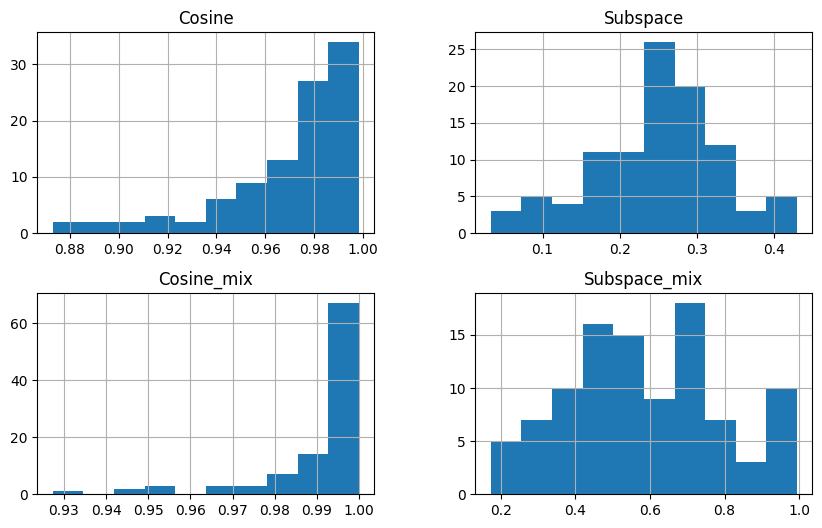

In [41]:
df[["Cosine","Subspace","Cosine_mix","Subspace_mix"]].hist(figsize=(10,6))